# Setup

In [1]:
# Standard library imports
import os
import time
import warnings

# choose the numerical engine BEFORE keras is imported — this line must come first
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data
import numpy as np
import pandas as pd

# Third-party imports: deep learning (Keras 3 on the PyTorch backend)
import torch
import keras
from keras.models import Sequential, Model
from keras.layers import Input, Dense, GRU, RepeatVector, TimeDistributed
from keras.callbacks import EarlyStopping

# Third-party imports: preprocessing & metrics
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Third-party imports: visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

print(f'keras {keras.__version__}, backend: {keras.backend.backend()}')

keras 3.15.0, backend: torch



This set of instructions prepares a Python environment for deep learning tasks, specifically time series forecasting using Keras with a PyTorch backend.

Initially, it imports necessary modules from the standard Python library – `os` for interacting with the operating system (like setting environment variables), `time` for time-related operations, and `warnings` to manage warning messages. 

Next, an important step is taken: the Keras backend is explicitly set to 'torch'. This must happen *before* importing Keras itself because it determines which deep learning framework Keras will use under the hood (in this case, PyTorch). The line `os.environ['KERAS_BACKEND'] = 'torch'` achieves this by setting an environment variable.

Following that, several third-party libraries are imported. `numpy` and `pandas` provide powerful tools for numerical computation and data manipulation, respectively.  The core Keras modules (`Sequential`, `Model`, `Input`, `Dense`, `GRU`, `RepeatVector`, `TimeDistributed`) are brought in to define and build neural network models. `EarlyStopping` is a callback function used during training to prevent overfitting. 

Additionally, libraries for more traditional machine learning (`Ridge` from scikit-learn) and evaluation metrics (`mean_squared_error`, `mean_absolute_error` from scikit-learn) are included. Finally, `matplotlib` is imported for creating visualizations of the data and model results.

The line `warnings.simplefilter(action='ignore', category=FutureWarning)` suppresses warnings related to future changes in Python or its libraries, keeping the output cleaner. 

Lastly, the code prints the versions of Keras being used and confirms that PyTorch is indeed the selected backend. This provides verification that the environment has been configured as intended.

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 16
    img_dim2 = 6
    SEED = 42
    LOOK_BACK = 28            # input window: four weeks of history per prediction
    HORIZON = 7               # forecast one week ahead in a single shot
    UNITS = 64                # width of the GRU hidden state
    SOURCE_STORE = 1          # data-rich source domain: all 50 items of this store
    TARGET_STORE = 10         # data-scarce target domain ...
    TARGET_ITEM = 15          # ... one item in a different store
    TARGET_HISTORY = 120      # days of target history we allow ourselves to see
    TEST_DAYS = 84            # final 12 weeks of the target series held out for testing
    PRETRAIN_EPOCHS = 8       # passes over the big source dataset
    PRETRAIN_BATCH = 256      # large batches for the large source set
    TARGET_EPOCHS = 200       # ceiling for target-side fits (early stopping decides)
    TARGET_BATCH = 32         # small batches for the small target set
    SOURCE_STRIDE = 2         # windowing stride on the source (thins overlapping windows)
    FT_LR = 1e-4              # gentle learning rate for fine-tuning pretrained weights

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

# reproducibility: seeds Python, NumPy and the deep learning backend in one call
keras.utils.set_random_seed(CFG.SEED)

This set of instructions defines configurations and initial settings for a time series forecasting project, likely involving transfer learning with recurrent neural networks (specifically GRUs).

The `CFG` class organizes various parameters. It specifies file paths for data (`data_folder`) and generated graphs (`graph_folder`). Image dimensions for visualization are set to 16x6 pixels (`img_dim1`, `img_dim2`). A random seed of 42 is established (`SEED`) to ensure reproducibility.

Key time series parameters include a look-back window of 28 days (`LOOK_BACK`), meaning the model uses four weeks of historical data for each prediction, and a forecast horizon of 7 days (`HORIZON`), indicating it predicts one week into the future. The GRU layer within the neural network will have 64 units (`UNITS`).

The code designates a source domain (store 1) with abundant data (`SOURCE_STORE`) and a target domain (store 10, item 15) where data is limited (`TARGET_STORE`, `TARGET_ITEM`). The amount of historical data used from the target domain is set to 120 days (`TARGET_HISTORY`), while the final 84 days are reserved for testing (`TEST_DAYS`).

Training parameters are also defined.  The source dataset will be used for pre-training the model over 8 epochs (`PRETRAIN_EPOCHS`) with a batch size of 256 (`PRETRAIN_BATCH`). The target domain training is capped at 200 epochs (`TARGET_EPOCHS`), but early stopping may terminate it sooner. A smaller batch size of 32 (`TARGET_BATCH`) is used for the target dataset.  A stride of 2 (`SOURCE_STRIDE`) is applied when creating windows from the source data, reducing overlap between them. Finally, a learning rate of 1e-4 (`FT_LR`) is set for fine-tuning the pre-trained model on the target domain.

Following the configuration settings, the code adjusts the plotting style using Seaborn (`plt.style.use("seaborn-v0_8")`) and sets a default figure size based on `img_dim1` and `img_dim2`. 

Lastly, it ensures reproducibility by setting random seeds for Python, NumPy, and Keras (`keras.utils.set_random_seed(CFG.SEED)`). This guarantees consistent results across multiple runs of the code.

In [3]:
# hardware: use the Apple silicon GPU when there is one, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'models will be created on: {DEVICE}')

models will be created on: mps


This portion of code determines which computational device will be used for running the machine learning model. 

It checks if Apple’s Metal Performance Shaders (MPS) backend is available in PyTorch, which indicates the presence of an Apple silicon GPU. If MPS is available, it assigns the string 'mps' to the `DEVICE` variable. Otherwise, it defaults to using the CPU by assigning 'cpu' to `DEVICE`. 

The code then prints a message indicating on which device models will be created, providing confirmation of the selected hardware. This allows users to quickly verify whether the GPU is being utilized for faster processing or if the program is falling back to the CPU.

# Utils

In [4]:
def forecast_metrics(y_true, y_pred):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': float(np.round(mae, 2)), 'RMSE': float(np.round(rmse, 2))}

This code defines a function called `forecast_metrics` that calculates and returns two common metrics used to evaluate the accuracy of time series forecasts: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The function takes two arguments, `y_true` and `y_pred`, which are expected to be arrays containing the actual (true) values and the predicted values, respectively. It’s assumed these arrays are aligned—meaning corresponding elements represent the same time point. 

Inside the function, it first calculates the MAE using the `mean_absolute_error` function from scikit-learn. Then, it computes the RMSE by calculating the square root of the mean squared error (obtained using `mean_squared_error` from scikit-learn).

Finally, the function returns a dictionary containing the calculated MAE and RMSE values. Both metrics are rounded to two decimal places using `np.round` and converted to floating-point numbers before being stored in the dictionary for clear presentation of results.

In [5]:
def make_windows(series, look_back, horizon, stride=1):
    """Slice a 1D array into (X, y) supervised pairs: look_back in, horizon out."""
    X, y = [], []
    for i in range(0, len(series) - look_back - horizon + 1, stride):
        X.append(series[i:i + look_back])
        y.append(series[i + look_back:i + look_back + horizon])
    X = np.array(X, dtype=np.float32).reshape(-1, look_back, 1)
    y = np.array(y, dtype=np.float32).reshape(-1, horizon)
    return X, y

This code defines a function called `make_windows` that prepares time series data for supervised learning, specifically for forecasting tasks. It transforms a one-dimensional array (a time series) into pairs of input sequences (X) and corresponding target values (y).

The function takes four arguments: the time series `series`, the length of the historical window to use as input (`look_back`), the number of steps ahead to predict (`horizon`), and an optional `stride` parameter that controls how much to shift the window for each step. The default stride is 1, meaning consecutive windows overlap by one data point.

The function initializes two empty lists, `X` and `y`, which will store the input sequences and target values respectively. It then iterates through the time series using a `for` loop with a specific range determined by `look_back`, `horizon`, and `stride`. 

Inside the loop, it extracts a segment of length `look_back` from the series starting at index `i` and appends it to the `X` list.  It then extracts the subsequent segment of length `horizon` (immediately following the input window) and appends it to the `y` list – this represents the target values we want to predict.

After processing the entire time series, the function converts the lists `X` and `y` into NumPy arrays with a data type of `np.float32`. It then reshapes these arrays to be suitable for input to a recurrent neural network (RNN) or similar model.  Specifically, `X` is reshaped to have dimensions (-1, `look_back`, 1), where -1 automatically infers the batch size and the last dimension of 1 represents a single feature. `y` is reshaped to (-1, `horizon`), representing batches of predicted values for each time step in the horizon.

Finally, the function returns the prepared input sequences `X` and target values `y`.

In [6]:
def make_test_windows(series, mean, std, test_days=CFG.TEST_DAYS):
    """Walk-forward test set: one origin per week, scaled inputs, labels in units."""
    z = ((series - mean) / std).to_numpy()      # inputs in the model's training scale
    raw = series.to_numpy()                     # labels stay in original units
    start = len(series) - test_days
    X, y = [], []
    for origin in range(start, len(series) - CFG.HORIZON + 1, CFG.HORIZON):
        X.append(z[origin - CFG.LOOK_BACK:origin])
        y.append(raw[origin:origin + CFG.HORIZON])
    X = np.array(X, dtype=np.float32).reshape(-1, CFG.LOOK_BACK, 1)
    return X, np.array(y, dtype=np.float32)

This code defines a function called `make_test_windows` that prepares data for walk-forward validation – a common technique for evaluating time series forecasting models. It creates test sets by sliding a window of historical data across the end of the time series, making predictions one week at a time.

The function takes the time series `series`, its mean and standard deviation (`mean`, `std`), and an optional number of test days (`test_days`) as input. The default value for `test_days` is taken from the global configuration object `CFG`.

First, it scales the entire time series by subtracting the mean and dividing by the standard deviation, storing the result in a NumPy array called `z`. This scaling ensures that the inputs to the model are within a similar range as those used during training. It also stores the original, unscaled data in a NumPy array named `raw`, which will be used for the target values (labels).

It then calculates the starting index (`start`) for creating the test windows based on the number of `test_days`. The code iterates through possible origins for each forecast window using a `for` loop.  The loop steps forward by `CFG.HORIZON` (one week) in each iteration, ensuring that each prediction is made one week ahead.

Inside the loop, it extracts a segment of length `CFG.LOOK_BACK` from the scaled series (`z`) starting at the current origin and appends it to the `X` list – this represents the input for the model. It then extracts the corresponding segment of length `CFG.HORIZON` from the original, unscaled series (`raw`) starting at the same origin and appends it to the `y` list – these are the actual values we want to predict (the labels).

After processing all possible origins, the function converts the lists `X` and `y` into NumPy arrays with a data type of `np.float32`. It reshapes `X` to have dimensions (-1, `CFG.LOOK_BACK`, 1) for compatibility with RNNs or similar models.

Finally, it returns the prepared input sequences `X` and target values `y`. The key difference from `make_windows` is that this function specifically prepares data for walk-forward validation using scaled inputs and original-scale labels, and it steps forward by the forecast horizon to simulate a real-world forecasting scenario.

In [7]:
def build_forecaster(units=CFG.UNITS, lr=1e-3):
    """GRU encoder + linear head, compiled for direct multi-step forecasting."""
    with keras.device(DEVICE):
        model = Sequential([
            Input(shape=(CFG.LOOK_BACK, 1)),
            GRU(units, name='encoder'),
            Dense(CFG.HORIZON, name='head'),
        ])
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr))
    return model

This code defines a function called `build_forecaster` that constructs a recurrent neural network (RNN) model for time series forecasting using Keras. Specifically, it builds a GRU-based encoder followed by a linear output layer.

The function takes two optional arguments: the number of units in the GRU layer (`units`), defaulting to the value specified in `CFG`, and the learning rate (`lr`) for the optimizer, defaulting to 1e-3.

Inside the function, it uses a `with keras.device(DEVICE):` block to ensure that the model is created on the appropriate device (GPU if available, otherwise CPU), as determined earlier by the `DEVICE` variable.

It then defines a sequential Keras model using `Sequential`. The model consists of three layers:
1.  An `Input` layer with a shape of (`CFG.LOOK_BACK`, 1). This specifies that the input to the model will be sequences of length `CFG.LOOK_BACK` with one feature (the time series value itself).
2.  A GRU (Gated Recurrent Unit) layer with `units` number of units, named 'encoder'. The GRU layer processes the input sequence and learns temporal dependencies.
3.  A Dense (fully connected) layer with `CFG.HORIZON` units, named 'head'. This layer maps the output of the GRU layer to a forecast for the next `CFG.HORIZON` time steps.

Finally, it compiles the model using the mean squared error (`mse`) loss function and the Adam optimizer with the specified learning rate (`lr`). The compiled model is then returned by the function. This resulting model is designed for direct multi-step forecasting – meaning it predicts all `CFG.HORIZON` future time steps in a single pass.

In [8]:
def fit_on(model, X_tr, y_tr, X_va, y_va, epochs=CFG.TARGET_EPOCHS,
           batch_size=CFG.TARGET_BATCH, patience=10, verbose=0):
    """Fit with early stopping on validation loss; return the History object."""
    early_stop = EarlyStopping(monitor='val_loss', patience=patience,
                               restore_best_weights=True)
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=[early_stop], verbose=verbose)
    print(f'stopped after {len(history.history["loss"])} epochs, '
          f'best val loss: {min(history.history["val_loss"]):.4f}')
    return history

This code defines a function called `fit_on` that trains a Keras model using the provided training and validation data, incorporating early stopping to prevent overfitting.

The function takes several arguments: the Keras model (`model`), the training input sequences (`X_tr`), the corresponding training target values (`y_tr`), the validation input sequences (`X_va`), the corresponding validation target values (`y_va`), the maximum number of epochs for training (`epochs`, defaulting to `CFG.TARGET_EPOCHS`), the batch size (`batch_size`, defaulting to `CFG.TARGET_BATCH`), the patience for early stopping (`patience`, defaulting to 10), and the verbosity level during training (`verbose`, defaulting to 0).

Inside the function, it creates an `EarlyStopping` callback that monitors the validation loss during training. If the validation loss does not improve for `patience` consecutive epochs, the training process will be stopped, and the model weights corresponding to the best validation loss encountered so far will be restored (`restore_best_weights=True`).

It then trains the model using the `fit` method of the Keras model. The training data is provided as `X_tr` and `y_tr`, and the validation data is provided as `(X_va, y_va)`. The training process runs for a maximum of `epochs` epochs with a batch size of `batch_size`. The `callbacks` argument includes the `early_stop` callback to enable early stopping.  The `verbose` argument controls the amount of output printed during training; setting it to 0 suppresses most output.

After training is complete (either by reaching the maximum number of epochs or by triggering the early stopping mechanism), the function prints a message indicating how many epochs were actually run and the best validation loss achieved during training, formatted to four decimal places.

Finally, the function returns the `history` object returned by the `fit` method. This object contains information about the training process, such as the loss and metrics values at each epoch for both the training and validation sets.

In [9]:
def evaluate_forecaster(model, X_test, y_true_units, mean, std):
    """Predict standardized test windows, convert back to units, score."""
    pred_units = model.predict(X_test, verbose=0) * std + mean
    return forecast_metrics(y_true_units.ravel(), pred_units.ravel())

This code defines a function called `evaluate_forecaster` that evaluates the performance of a trained forecasting model on a test dataset.

The function takes four arguments: the trained Keras model (`model`), the test input sequences (`X_test`), the true target values in their original units (`y_true_units`), and the mean and standard deviation used for scaling the data during training (`mean`, `std`).

Inside the function, it first makes predictions on the test data using the `predict` method of the model. The `verbose=0` argument suppresses output during prediction.  The predicted values are initially in standardized units (i.e., scaled by subtracting the mean and dividing by the standard deviation). To convert them back to the original units, it multiplies the predictions by the standard deviation (`std`) and adds the mean (`mean`). The result is stored in `pred_units`.

Finally, it calls the `forecast_metrics` function (defined previously) to calculate the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) between the flattened true target values (`y_true_units.ravel()`) and the flattened predicted values (`pred_units.ravel()`). The resulting dictionary containing the MAE and RMSE is then returned by the function, providing a measure of the model's forecasting accuracy on the test set.

In [10]:
def plot_test_forecasts(observed, forecasts, title):
    """Overlay observed test data with one or more stitched weekly forecasts.

    observed:  pd.Series over the test period (original units)
    forecasts: dict of label -> array (n_weeks, HORIZON) in original units
    """
    plt.figure()
    observed.plot(linewidth=2, label='observed', xlabel="")
    colors = ['red', 'green', 'purple', 'orange']
    for (label, preds), color in zip(forecasts.items(), colors):
        stitched = pd.Series(np.asarray(preds).ravel()[:len(observed)],
                             index=observed.index)
        stitched.plot(linestyle='--', marker='o', markersize=3,
                      color=color, label=label)
    plt.title(title)
    plt.ylabel('units sold')
    plt.legend()
    plt.show()

This code defines a function called `plot_test_forecasts` that visualizes the performance of a forecasting model by plotting observed test data alongside its forecasts.

The function takes two arguments: `observed`, which is a Pandas Series representing the actual values during the test period (in original units), and `forecasts`, which is a dictionary containing one or more sets of forecast predictions. The keys of the dictionary are labels for each set of forecasts, and the values are NumPy arrays with shape (number of weeks, `CFG.HORIZON`) representing the weekly forecasts in original units.  The third argument, `title`, provides a title for the plot.

Inside the function, it creates a new Matplotlib figure using `plt.figure()`. It then plots the observed data as a line with a linewidth of 2 and labels it 'observed', removing the x-axis label to avoid clutter.

It iterates through the forecasts in the `forecasts` dictionary using `zip(forecasts.items(), colors)`, pairing each forecast set (label, predictions) with a color from a predefined list (`colors`). For each forecast set:
1.  It stitches together the weekly forecasts into a single Pandas Series called `stitched`. It uses `np.asarray(preds).ravel()[:len(observed)]` to flatten the array of forecasts and truncate it to the length of the observed data, ensuring that only the relevant portion of the forecast is plotted. The index of the stitched series is set to match the index of the observed series.
2.  It plots the `stitched` series as a dashed line with markers ('o') of size 3, using the assigned color and labeling it with the corresponding label from the dictionary.

Finally, it sets the title of the plot to the provided `title`, labels the y-axis as 'units sold', displays a legend to identify the observed data and each forecast set, and shows the plot using `plt.show()`. This function provides a clear visual comparison between the actual test data and the model's predictions.

# Groundwork

In [11]:
# load the raw panel and carve out the two domains
raw = pd.read_csv(CFG.data_folder + 'train.csv', parse_dates=['date'])

# source: store 1, all 50 items, as a (days x items) matrix
source_panel = (raw[raw.store == CFG.SOURCE_STORE]
                .pivot(index='date', columns='item', values='sales'))

# target: one item in a different store, as a single series
target = (raw[(raw.store == CFG.TARGET_STORE) & (raw.item == CFG.TARGET_ITEM)]
          .set_index('date')['sales'])

print(f'source panel: {source_panel.shape[0]} days x {source_panel.shape[1]} items')
print(f'target series: {len(target)} days, {target.index.min().date()} to {target.index.max().date()}')
source_panel.head(3)

source panel: 1826 days x 50 items
target series: 1826 days, 2013-01-01 to 2017-12-31


item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13,33,15,10,11,31,25,33,18,37,...,6,21,22,20,37,30,17,21,18,30
2013-01-02,11,43,30,11,6,36,23,37,23,34,...,15,24,27,15,40,30,15,26,10,32
2013-01-03,14,23,14,8,8,18,34,38,25,32,...,5,14,19,11,42,30,5,25,17,25


This code loads and prepares the time series data for a transfer learning experiment, separating it into source and target domains.

First, it reads the training data from a CSV file specified by `CFG.data_folder + 'train.csv'` using Pandas' `read_csv` function. The `parse_dates=['date']` argument ensures that the 'date' column is parsed as datetime objects.  The resulting DataFrame is stored in the variable `raw`.

Next, it creates a source panel representing data from store 1 and all 50 items. It filters the `raw` DataFrame to include only rows where the 'store' column equals `CFG.SOURCE_STORE` (which is set to 1). Then, it uses the `pivot` function to reshape the data into a matrix with dates as the index, items as columns, and sales as values. This creates a panel-like structure where each row represents a day and each column represents an item's sales in that store. The resulting source panel is stored in the variable `source_panel`.

Then, it extracts the target time series representing data from a specific item in a different store. It filters the `raw` DataFrame to include only rows where the 'store' column equals `CFG.TARGET_STORE` (10) and the 'item' column equals `CFG.TARGET_ITEM` (15).  It then sets the 'date' column as the index of the resulting DataFrame and selects only the 'sales' column, creating a Pandas Series representing the sales time series for that specific item in that store. The result is stored in the variable `target`.

Finally, it prints information about the shape of the source panel (number of days and items) and the length and date range of the target series to provide an overview of the data. It also displays the first three rows of the `source_panel` DataFrame using `.head(3)` for a quick inspection of its contents. This prepares the data into two distinct datasets: a rich source domain with many items and a sparse target domain with only one item, suitable for transfer learning techniques.

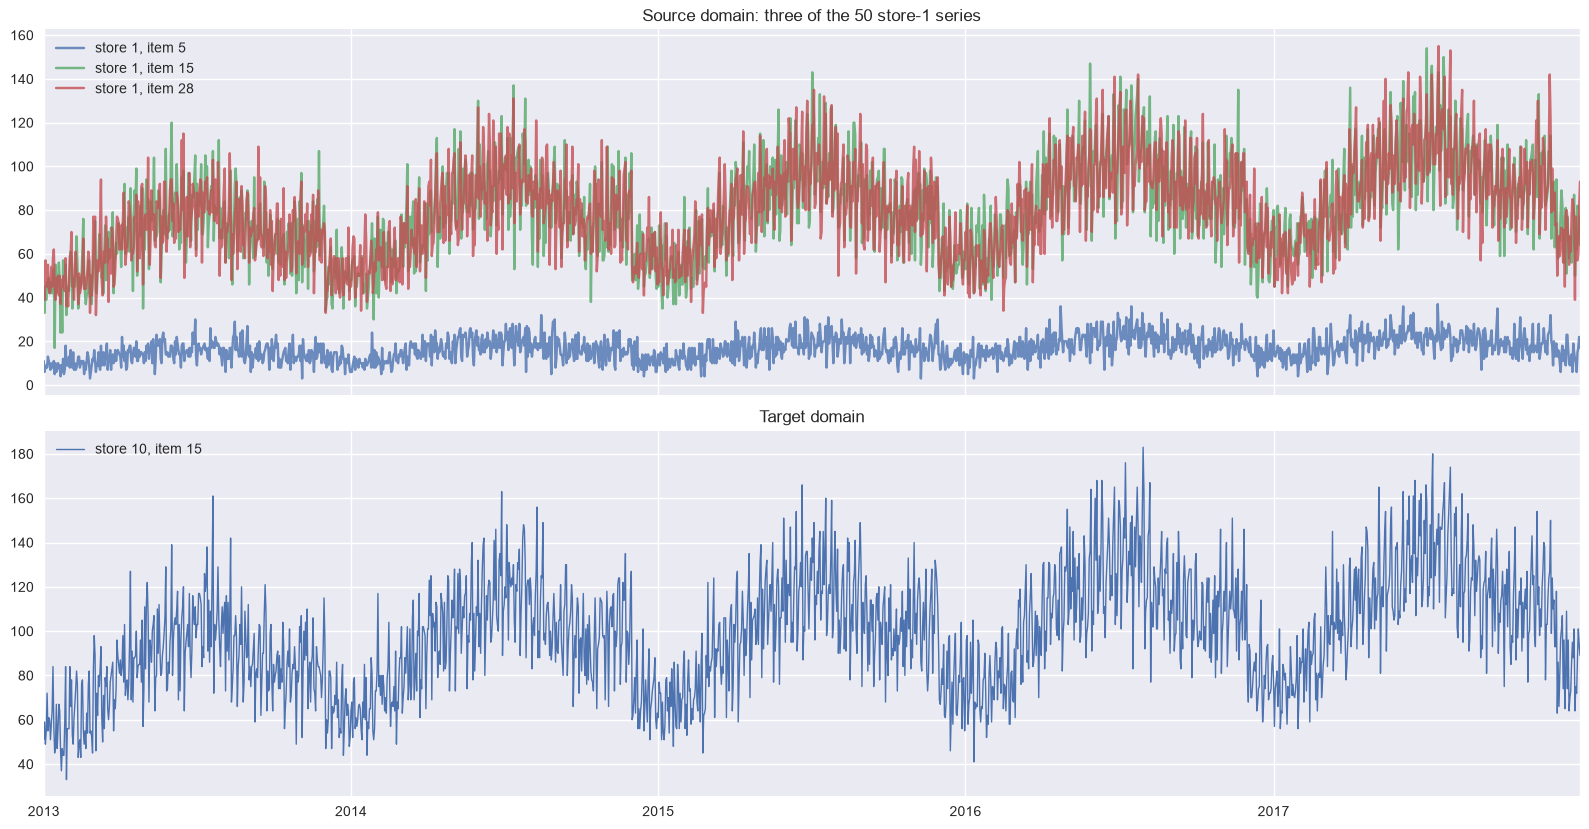

In [12]:
# a first look at both domains
fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, CFG.img_dim2 * 1.4), sharex=True)

# top: a few source series
for item in [5, 15, 28]:
    source_panel[item].plot(ax=axes[0], alpha=0.8, label=f'store 1, item {item}')
axes[0].set_title('Source domain: three of the 50 store-1 series')
axes[0].legend()

# bottom: the target series
target.plot(ax=axes[1], linewidth=1, label=f'store 10, item {CFG.TARGET_ITEM}')
axes[1].set_title('Target domain')
axes[1].set_xlabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

This code generates a visualization to provide an initial comparison between the source and target time series data.

It first creates a figure with two subplots arranged vertically using `plt.subplots`. The `figsize` argument sets the overall size of the figure based on the dimensions defined in `CFG`, and `sharex=True` ensures that both subplots share the same x-axis (date).

The top subplot (`axes[0]`) displays a few sample time series from the source domain. It iterates through a list of item IDs ([5, 15, 28]) and plots the corresponding sales data from the `source_panel` for each item on the same subplot using different alpha values (transparency) to distinguish them. Each line is labeled with the store and item number. A title 'Source domain: three of the 50 store-1 series' is added, and a legend is displayed to identify each time series.

The bottom subplot (`axes[1]`) displays the target time series. It plots the `target` Series on this subplot with a linewidth of 1 and labels it appropriately. A title 'Target domain' is added, and the x-axis label is removed to avoid redundancy since it’s shared with the top plot. A legend is also displayed for clarity.

Finally, `plt.tight_layout()` adjusts the spacing between subplots to prevent overlapping elements, and `plt.show()` displays the resulting figure. This visualization allows a quick assessment of the characteristics of both datasets – the source domain's diversity across multiple items and the target domain’s single time series – helping to understand the challenges and potential benefits of transfer learning in this context.

scarce train: 2017-06-11 to 2017-10-08 (120 days)
test:         2017-10-09 to 2017-12-31 (84 days)


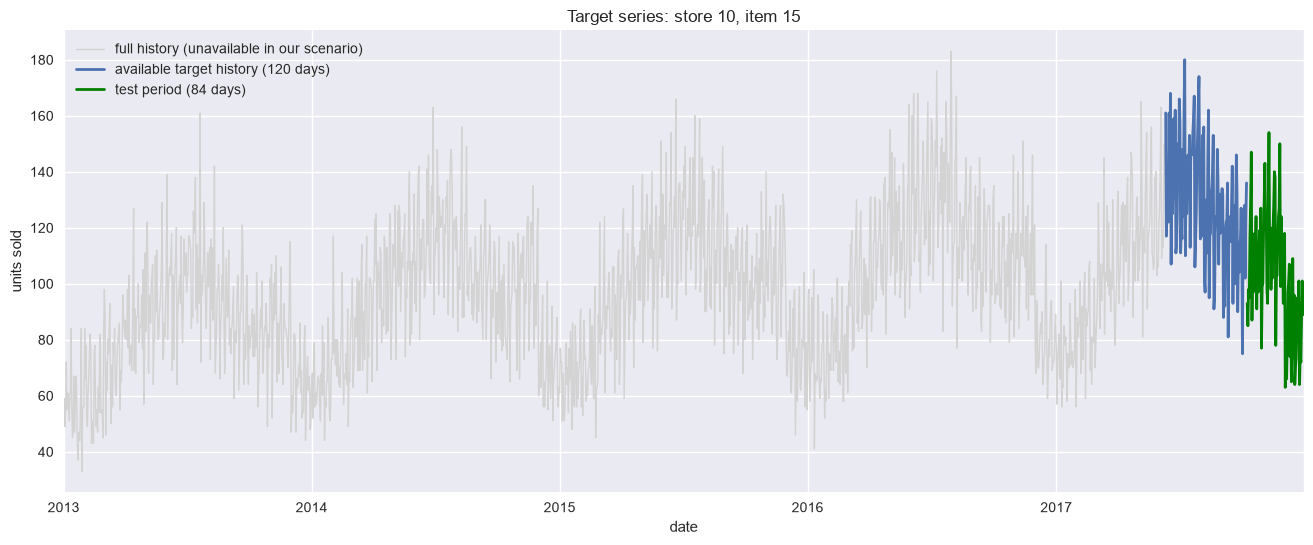

In [13]:
# chronological carve-up of the target: (ignored history | 120-day train | 84-day test)
test = target.iloc[-CFG.TEST_DAYS:]
history = target.iloc[:-CFG.TEST_DAYS]
scarce = history.iloc[-CFG.TARGET_HISTORY:]

print(f'scarce train: {scarce.index.min().date()} to {scarce.index.max().date()} ({len(scarce)} days)')
print(f'test:         {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)')

# visualize the split
plt.figure()
target.plot(linewidth=1, color='lightgray', label='full history (unavailable in our scenario)')
scarce.plot(linewidth=2, label='available target history (120 days)')
test.plot(linewidth=2, color='green', label='test period (84 days)')
plt.title(f'Target series: store {CFG.TARGET_STORE}, item {CFG.TARGET_ITEM}')
plt.ylabel('units sold')
plt.legend()
plt.show()

This code divides the target time series into three segments: a portion representing ignored historical data, a training set with limited history (`scarce`), and a test set for evaluating model performance. This simulates a realistic scenario where only a short period of historical data is available for the target domain.

First, it splits the `target` Series into two parts: `test` and `history`. The `test` segment consists of the last `CFG.TEST_DAYS` (84) days of the series, representing the hold-out test set. The remaining portion is assigned to `history`, representing all data before the test period.

Next, it further divides the `history` segment into two parts: a longer historical segment that's considered unavailable for training and the `scarce` training set.  The `scarce` segment consists of the last `CFG.TARGET_HISTORY` (120) days of the `history` series, representing the limited amount of target domain data available for training.

It then prints information about the date ranges and lengths of both the `scarce` training set and the `test` set to confirm the split.

Finally, it creates a visualization to illustrate the division of the target time series. It plots the entire `target` Series in light gray as a reference (labeled 'full history (unavailable in our scenario)'), the `scarce` training set in a thicker line (labeled 'available target history (120 days)'), and the `test` set in green (labeled 'test period (84 days)'). A title is added indicating the store and item number, and the y-axis is labeled as 'units sold'.  A legend clarifies which segment corresponds to each line. This plot visually demonstrates how a limited amount of target domain data is used for training while reserving a separate test set for evaluation.

In [14]:
# standardize using ONLY the scarce training history, then window
t_mean, t_std = scarce.mean(), scarce.std()
print(f'target scaling stats (from the 120 training days only): mean={t_mean:.1f}, std={t_std:.1f}')

scarce_z = ((scarce - t_mean) / t_std).to_numpy()
X_target, y_target = make_windows(scarce_z, CFG.LOOK_BACK, CFG.HORIZON)

# chronological train/validation split of the windows
N_VAL = max(8, int(0.2 * len(X_target)))
X_tr, y_tr = X_target[:-N_VAL], y_target[:-N_VAL]
X_va, y_va = X_target[-N_VAL:], y_target[-N_VAL:]

print(f'target windows: {len(X_target)} total = {len(X_tr)} train + {len(X_va)} validation')
print(f'input tensor: {X_tr.shape}, labels: {y_tr.shape}')

target scaling stats (from the 120 training days only): mean=128.3, std=21.2
target windows: 86 total = 69 train + 17 validation
input tensor: (69, 28, 1), labels: (69, 7)


This code prepares the target time series data for training a forecasting model by standardizing it using statistics calculated *only* from the limited available training history and then creating supervised learning windows.

First, it calculates the mean (`t_mean`) and standard deviation (`t_std`) of the `scarce` Series (the 120-day target training data). It’s crucial to use only this data for standardization because we want to simulate a realistic scenario where information about the entire time series is not available during training. The calculated mean and standard deviation are printed for inspection.

Next, it standardizes the `scarce` Series by subtracting the calculated mean (`t_mean`) and dividing by the standard deviation (`t_std`). This scaled data is stored in a NumPy array called `scarce_z`.

It then calls the `make_windows` function (defined earlier) to transform the standardized time series (`scarce_z`) into supervised learning pairs of input sequences (X) and target values (y). The `CFG.LOOK_BACK` and `CFG.HORIZON` parameters determine the length of the input window and the forecast horizon, respectively.  The resulting input sequences are stored in `X_target`, and the corresponding target values are stored in `y_target`.

Finally, it splits the created windows into training and validation sets. It calculates the number of validation samples (`N_VAL`) as 20% of the total number of windows, with a minimum value of 8 to ensure sufficient data for validation.  It then divides `X_target` and `y_target` into training sets (`X_tr`, `y_tr`) containing all but the last `N_VAL` samples and validation sets (`X_va`, `y_va`) containing the last `N_VAL` samples, maintaining chronological order.

The code concludes by printing information about the number of windows in each set (total, train, and validation) and the shape of the input tensor (`X_tr`) and labels (`y_tr`), confirming that the data is properly prepared for training. This ensures that the model is trained and validated on a representative subset of the limited target domain data while respecting the temporal order of the time series.

In [15]:
# test windows: walk-forward, one forecast origin per week, labels kept in units
X_test, y_test_units = make_test_windows(target, t_mean, t_std)
print(f'test windows: {X_test.shape[0]} weekly origins, inputs {X_test.shape}, labels {y_test_units.shape}')

test windows: 12 weekly origins, inputs (12, 28, 1), labels (12, 7)


This code prepares the test data for evaluating the forecasting model using a walk-forward approach, ensuring that predictions are made one week at a time and that the target values remain in their original units.

It calls the `make_test_windows` function (defined previously) to create the test set. The function takes the original `target` Series, the mean (`t_mean`) and standard deviation (`t_std`) calculated from the scarce training data, and uses these statistics for scaling the input features during testing. This is important because it ensures consistency between the training and testing phases – the test inputs are scaled using the same parameters as the training inputs.

The `make_test_windows` function returns two NumPy arrays: `X_test`, which contains the standardized input sequences (historical data) for each forecast origin, and `y_test_units`, which contains the corresponding target values (actual sales) in their original units.

Finally, it prints information about the shape of the test set, indicating the number of weekly forecast origins (`X_test.shape[0]`), the shape of the input sequences (`X_test.shape`), and the shape of the target values (`y_test_units.shape`). This confirms that the test data is properly prepared for evaluating the model's forecasting performance in a realistic walk-forward manner, with labels remaining in their original units for easier interpretation.

In [16]:
# two naive baselines every method must beat
results = {}

# persistence: tomorrow (and the next 6 days) = today
persistence = np.repeat(X_test[:, -1, 0].reshape(-1, 1), CFG.HORIZON, axis=1) * t_std + t_mean
results['persistence'] = forecast_metrics(y_test_units.ravel(), persistence.ravel())

# seasonal naive: next week = last week
seasonal_naive_pred = X_test[:, -CFG.HORIZON:, 0] * t_std + t_mean
results['seasonal naive'] = forecast_metrics(y_test_units.ravel(), seasonal_naive_pred.ravel())

print('persistence:   ', results['persistence'])
print('seasonal naive:', results['seasonal naive'])

persistence:    {'MAE': 24.14, 'RMSE': 29.04}
seasonal naive: {'MAE': 13.61, 'RMSE': 17.97}


This code establishes two simple baseline forecasting methods – persistence and seasonal naiveté – against which the performance of more complex models will be compared.

It initializes an empty dictionary called `results` to store the evaluation metrics for each method.

First, it implements a *persistence* model, which predicts that tomorrow's value will be equal to today's value (and extends this prediction for the entire forecast horizon). It extracts the last value from each input sequence in `X_test` (`X_test[:, -1, 0]`), reshapes it to have one column, and then repeats this value `CFG.HORIZON` times to create a forecast for the next week. The standardized predictions are then converted back to original units by multiplying by `t_std` and adding `t_mean`.  The performance of this persistence model is evaluated using the `forecast_metrics` function, with the results stored in the `results` dictionary under the key 'persistence'.

Next, it implements a *seasonal naiveté* model, which predicts that next week's values will be equal to the corresponding values from last week. It extracts the last `CFG.HORIZON` values from each input sequence in `X_test` (`X_test[:, -CFG.HORIZON:, 0]`), converts them back to original units, and uses these as the forecast for the next week. The performance of this seasonal naiveté model is evaluated using `forecast_metrics`, with the results stored in the `results` dictionary under the key 'seasonal naive'.

Finally, it prints the evaluation metrics (MAE and RMSE) for both baseline models to provide a benchmark for assessing the effectiveness of more sophisticated forecasting techniques. Any model that cannot outperform these simple baselines is likely not providing meaningful improvements.

# The transfer learning ladder

Six rungs, one new ingredient each. Every rung trains (or reuses) the *same* GRU-encoder-plus-linear-head architecture and is evaluated by the *same* walk-forward protocol on the *same* twelve test weeks — so the numbers are directly comparable, and the only thing that changes between rungs is **where the weights come from**.

## Rung 1 — from scratch on the target

The no-transfer reference point: random initialization, 69 training windows, and hope. Everything later in the notebook is measured against this.

In [17]:
keras.utils.set_random_seed(CFG.SEED)

scratch_model = build_forecaster()
print(f'parameters: {scratch_model.count_params():,} '
      f'(encoder {scratch_model.get_layer("encoder").count_params():,}, '
      f'head {scratch_model.get_layer("head").count_params():,})')

fit_on(scratch_model, X_tr, y_tr, X_va, y_va)
results['from scratch'] = evaluate_forecaster(scratch_model, X_test, y_test_units, t_mean, t_std)
print('from scratch:', results['from scratch'])

parameters: 13,319 (encoder 12,864, head 455)


stopped after 59 epochs, best val loss: 0.5089
from scratch: {'MAE': 15.82, 'RMSE': 20.05}


Re-seeding immediately before each model build is a small discipline worth adopting: it means every rung starts from the *same* random initialization stream, so reruns of any single section reproduce its numbers without executing the whole notebook in order.

The parameter printout frames the problem: **13,319 parameters** (12,864 in the GRU encoder, 455 in the head) against 69 training windows containing at most `69 × 35 = 2,415` observed values, most of them shared between overlapping windows. This is the textbook overfitting configuration; early stopping is the only thing standing between the network and pure memorization, and the validation loss it settles at — read the printed line — remains well above what the transfer rungs will reach: the network stops not because it has learned the problem, but because 69 windows have nothing more to teach it.

The result: around **RMSE 20 / MAE 15.8**. Recall the bar set in the groundwork: seasonal naive scored RMSE 18. The deep network, trained from scratch on four months of data, *loses to copy-last-week*. This deserves to be stated bluntly because it is the single most common failure mode of deep learning on short series — and the standard argument for either staying with simple statistical methods or, as we are about to do, importing knowledge from elsewhere. Data-hungry models need data; when the target cannot supply it, some other series must.

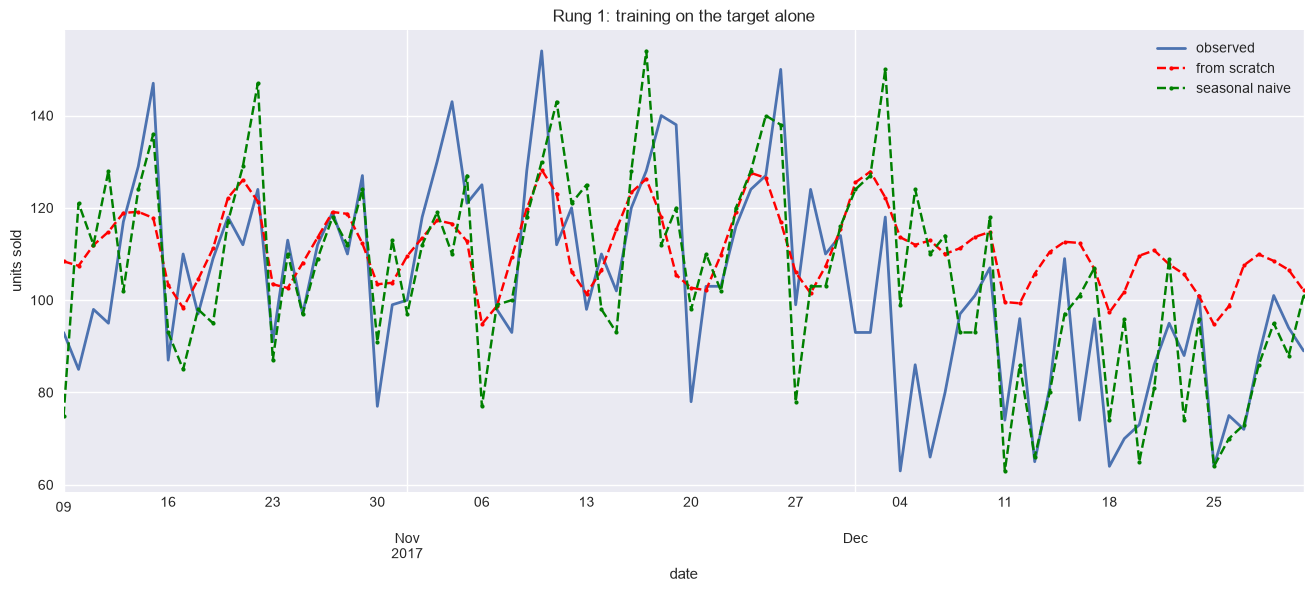

In [18]:
scratch_pred = scratch_model.predict(X_test, verbose=0) * t_std + t_mean
plot_test_forecasts(test, {'from scratch': scratch_pred,
                           'seasonal naive': seasonal_naive_pred},
                    'Rung 1: training on the target alone')

The picture behind the numbers. The scratch network has learned the weekly oscillation — the wiggles are in the right places, courtesy of walk-forward re-observation feeding it fresh true history every week — but its amplitude and level tracking are visibly loose, and through the year-end decline it drifts because nothing in its 120 training days told it that demand falls in winter. Seasonal naive, plotted alongside, tracks the level almost embarrassingly well for a method with no parameters at all; its weakness is being exactly one week behind every change. Keep both failure patterns in mind — the transfer rungs will fix the network's, not the baseline's.

## Rung 2 — supervised pretraining and zero-shot transfer

**New ingredient: a source domain.** We train the identical architecture on the 50 store-1 series — a *supervised* pretraining, since the source task (predict the next week from the last four) is the same as the target task and the source labels come free with the data. Then we apply the pretrained network to the target with **zero adaptation**: no target training at all, in analogy to what the foundation-model literature calls *zero-shot forecasting*.

In [19]:
# build the source training set: window each store-1 series in its own scale
VAL_TAIL = 120   # last 120 days of each source series held out for validation

X_src_tr, y_src_tr, X_src_va, y_src_va = [], [], [], []
for item in source_panel.columns:
    series = source_panel[item].iloc[:-CFG.TEST_DAYS]          # align with target test period
    m, s = series.mean(), series.std()
    z = ((series - m) / s).to_numpy()
    Xa, ya = make_windows(z[:-VAL_TAIL], CFG.LOOK_BACK, CFG.HORIZON, stride=CFG.SOURCE_STRIDE)
    Xb, yb = make_windows(z[-VAL_TAIL:], CFG.LOOK_BACK, CFG.HORIZON, stride=CFG.SOURCE_STRIDE)
    X_src_tr.append(Xa); y_src_tr.append(ya)
    X_src_va.append(Xb); y_src_va.append(yb)

X_src_tr = np.concatenate(X_src_tr); y_src_tr = np.concatenate(y_src_tr)
X_src_va = np.concatenate(X_src_va); y_src_va = np.concatenate(y_src_va)
print(f'source windows: {len(X_src_tr):,} train, {len(X_src_va):,} validation')

source windows: 39,700 train, 2,150 validation


The source dataset construction, with three deliberate choices. First, **each series is standardized by its own statistics** before windowing — the portability trick from the groundwork, applied 50 times; the network will see 50 series that all live on the same "standard deviations around my own level" scale. Second, each source series is truncated at the same calendar date as the target's test start, so no model in this notebook — pretrained or not — has seen *any* data from the test months, even from other stores; the comparison across rungs stays temporally clean. Third, the chronological pattern repeats in miniature: the last `VAL_TAIL` days of each series are reserved as pretraining validation, and windows are extracted at `stride=2`.

The yield: roughly **40,000 training windows** — five hundred times the target's 69. This is the "data-rich source domain" of the transfer learning literature made concrete.

In [20]:
keras.utils.set_random_seed(CFG.SEED)
pretrained_model = build_forecaster()

start = time.time()
pretrained_model.fit(X_src_tr, y_src_tr,
                     validation_data=(X_src_va, y_src_va),
                     epochs=CFG.PRETRAIN_EPOCHS, batch_size=CFG.PRETRAIN_BATCH,
                     verbose=2)
print(f'pretraining took {time.time() - start:.0f} s')

pretrained_weights = pretrained_model.get_weights()

Epoch 1/8


156/156 - 2s - 13ms/step - loss: 0.5394 - val_loss: 0.6258


Epoch 2/8


156/156 - 2s - 13ms/step - loss: 0.4292 - val_loss: 0.4967


Epoch 3/8


...

Epoch 7/8


156/156 - 2s - 12ms/step - loss: 0.3510 - val_loss: 0.4252


Epoch 8/8


156/156 - 2s - 13ms/step - loss: 0.3504 - val_loss: 0.4281


pretraining took 16 s


Pretraining itself is unremarkable by design — same architecture, same MSE loss, just five hundred times more data and correspondingly larger batches (`PRETRAIN_BATCH = 256`; with ~156 gradient steps per epoch, eight epochs suffice and the whole thing takes well under a minute on the MPS device). Watch the printed losses: training and validation loss land close together, around 0.35–0.43 in standardized units. No early stopping theatrics are needed here — with this much data relative to 13k parameters, overfitting is not a live concern; the regime is the exact opposite of rung 1.

The last line is the entire point of the exercise: **`get_weights()`** extracts the learned parameters as a list of NumPy arrays. That list — a few kilobytes of floats — is the distilled experience of five years times fifty series, and every remaining rung of the ladder is a different opinion about what to do with it.

In [21]:
# zero-shot: apply the source model to the target, no adaptation whatsoever
results['zero-shot transfer'] = evaluate_forecaster(pretrained_model, X_test,
                                                    y_test_units, t_mean, t_std)
print('zero-shot transfer:', results['zero-shot transfer'])

zero-shot transfer: {'MAE': 12.65, 'RMSE': 15.63}


One line, and it is the most instructive line of the notebook: a model that has **never seen a single store-10 observation** scores around **RMSE 15.6** — beating the from-scratch network (20) by a wide margin *and* clearing the seasonal naive bar (18) that scratch could not. This works for two reasons worth separating. Mechanically, per-series standardization means the target inputs arrive in the same shape-language the network was trained on, so the transfer is well-posed at all. Statistically, the *dynamics* of item-level demand — weekly rhythm, the way peaks decay, the autumn slide the target's own 120 days never showed — are shared across stores, and 40,000 source windows estimate them far better than 69 target windows ever could.

This is, in miniature, the pitch of time series foundation models: pretrain once on a large corpus, deploy zero-shot on series you have never seen. It also sets up the natural next question — if *ignoring* the target's data entirely already wins, can its 69 windows buy us anything more? That is fine-tuning, in two flavors.

## Rung 3 — fine-tune the head only

**New ingredient: adaptation on target labels — with the encoder frozen.** The literature calls this *partial-parameter supervised fine-tuning*: keep the pretrained representation fixed, retrain only the small task head. With 455 trainable parameters against 69 windows, overfitting is nearly impossible — this is the safest way to spend scarce target labels.

In [22]:
keras.utils.set_random_seed(CFG.SEED)

head_ft_model = build_forecaster()
head_ft_model.set_weights(pretrained_weights)          # transplant ALL pretrained weights
head_ft_model.get_layer('encoder').trainable = False   # ... then freeze the encoder
head_ft_model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=1e-3))

trainable = sum(int(np.prod(w.shape)) for w in head_ft_model.trainable_weights)
print(f'trainable parameters after freezing: {trainable} of {head_ft_model.count_params():,}')

fit_on(head_ft_model, X_tr, y_tr, X_va, y_va)
results['head-only fine-tune'] = evaluate_forecaster(head_ft_model, X_test,
                                                     y_test_units, t_mean, t_std)
print('head-only fine-tune:', results['head-only fine-tune'])

trainable parameters after freezing: 455 of 13,319


stopped after 16 epochs, best val loss: 0.3313
head-only fine-tune: {'MAE': 12.3, 'RMSE': 15.36}


The mechanics of transfer surgery, step by step. A fresh model is stamped out by the factory, **`set_weights(pretrained_weights)`** overwrites its random initialization with the pretrained arrays (the architectures match exactly, so the weight lists align one-to-one), and **`.trainable = False`** on the encoder layer excludes its 12,864 parameters from gradient updates. The gotcha: **`trainable` changes only take effect at `compile` time** — Keras builds its training function when you compile, so flipping the flag afterwards without recompiling would silently train the encoder anyway. Hence the explicit recompile, and the printed confirmation that only the head's 455 parameters remain trainable. Since the encoder is frozen at pretrained values (not random ones), the full Adam rate `1e-3` is appropriate for the fresh head.

The result improves on zero-shot by a modest step — around **RMSE 15.4**. The interpretation: the head adjustment lets the model calibrate its readout to this particular series (its noise level, its slightly different weekly profile), but the representation itself is still purely store-1 knowledge. Freezing has a second virtue the numbers don't show: it makes **catastrophic forgetting** — the destruction of pretrained features by aggressive updates on a tiny dataset — structurally impossible.

## Rung 4 — full fine-tuning

**New ingredient: unfreezing, at a gentle learning rate.** *Full-parameter fine-tuning* lets the target data reshape the entire network, encoder included. It is the most expressive adaptation — and the most dangerous one in a low-data regime, which is why its two safety rails matter: a learning rate ten times smaller than the default, and early stopping.

In [23]:
keras.utils.set_random_seed(CFG.SEED)

full_ft_model = build_forecaster(lr=CFG.FT_LR)      # note: gentle learning rate
full_ft_model.set_weights(pretrained_weights)

fit_on(full_ft_model, X_tr, y_tr, X_va, y_va)
results['full fine-tune'] = evaluate_forecaster(full_ft_model, X_test,
                                                y_test_units, t_mean, t_std)
print('full fine-tune:', results['full fine-tune'])

stopped after 84 epochs, best val loss: 0.2882
full fine-tune: {'MAE': 11.58, 'RMSE': 14.85}


Structurally the smallest cell of the ladder — transplant the weights, train everything — because all the safety engineering hides in two arguments. **`lr=CFG.FT_LR`** (1e-4): starting from good weights, large steps could only destroy information before rebuilding it from 69 windows, which cannot end well; small steps *adjust*. And `fit_on`'s early stopping now acts as the second rail, halting the process the moment validation loss suggests the encoder has started memorizing the target's noise. This pairing — small learning rate plus early stopping, sometimes with explicit weight decay toward the pretrained values — is the standard recipe wherever full fine-tuning meets scarce labels.

The payoff is the best score so far: around **RMSE 14.9 / MAE 11.6**, a further step past the frozen-encoder variant. The ordering that emerges — scratch 20 → zero-shot 15.6 → head-only 15.4 → full FT 14.9 — is the canonical transfer learning result, worth internalizing as a hierarchy of *how much the target data is trusted*: not at all (zero-shot), only to calibrate the readout (head-only), or to gently reshape the representation itself (full). With more target data the ordering's gaps shift — the sample-efficiency section will map exactly how.

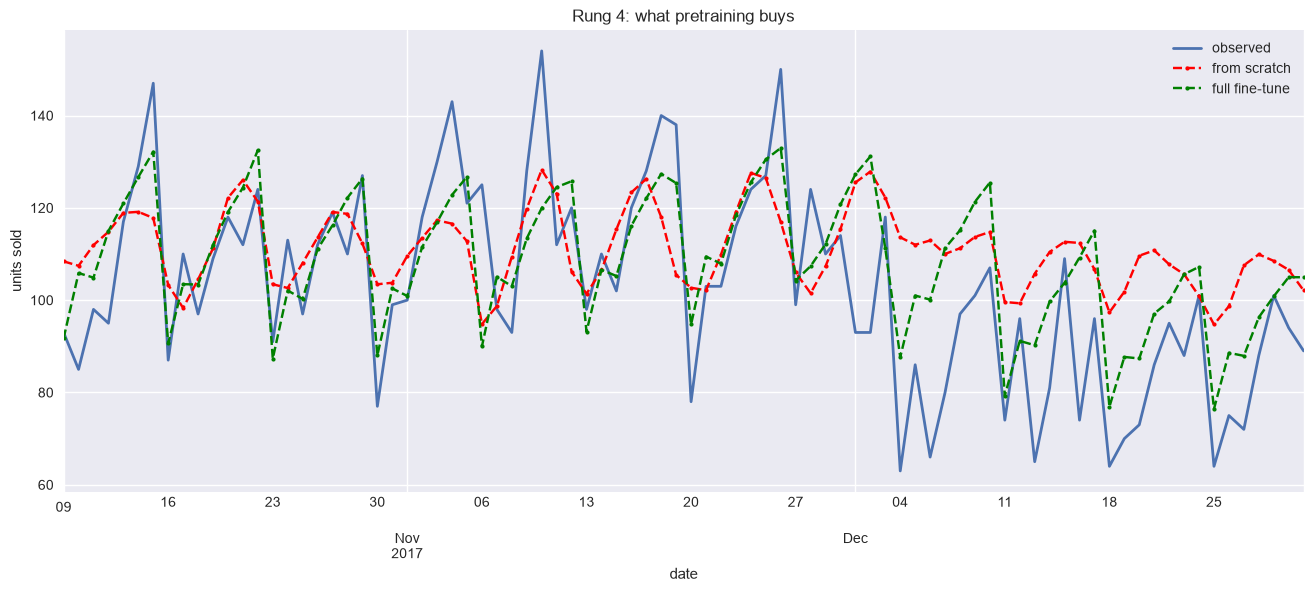

In [24]:
full_ft_pred = full_ft_model.predict(X_test, verbose=0) * t_std + t_mean
plot_test_forecasts(test, {'from scratch': scratch_pred,
                           'full fine-tune': full_ft_pred},
                    'Rung 4: what pretraining buys')

Scratch and full fine-tune, side by side. The fine-tuned forecast holds the weekly amplitude steadily and — the decisive difference — *follows the year-end decline down*, because the pretrained encoder watched four winters happen in fifty other series. The scratch model, whose entire worldview is one summer and one autumn, has no reason to expect December to differ. This is transfer learning's contribution in one picture: not sharper wiggles, but **imported seasonal context** the target's own history could never provide.

## Rung 5 — self-supervised pretraining: the masked autoencoder

**New ingredient: pretraining without labels.** Supervised pretraining worked because forecasting labels come free — the "label" is just the next week of the series. But suppose the source data supported no such task (heterogeneous horizons, or no forecasting task at all): the modern answer is a **pretext task**, an artificial objective that forces the network to learn structure without any labels. The *generative/reconstructive* family — from TimeNet's GRU autoencoder to Ti-MAE's masked transformers — corrupts the input and trains the model to reconstruct the original. We build the recurrent version: mask 40% of each source window, encode what remains into a single vector, and demand the decoder rebuild the whole window from it. A model that can infill masked demand data has provably learned something about weekly rhythm and local trend; the open question — answered honestly below — is whether *that* something helps forecasting.

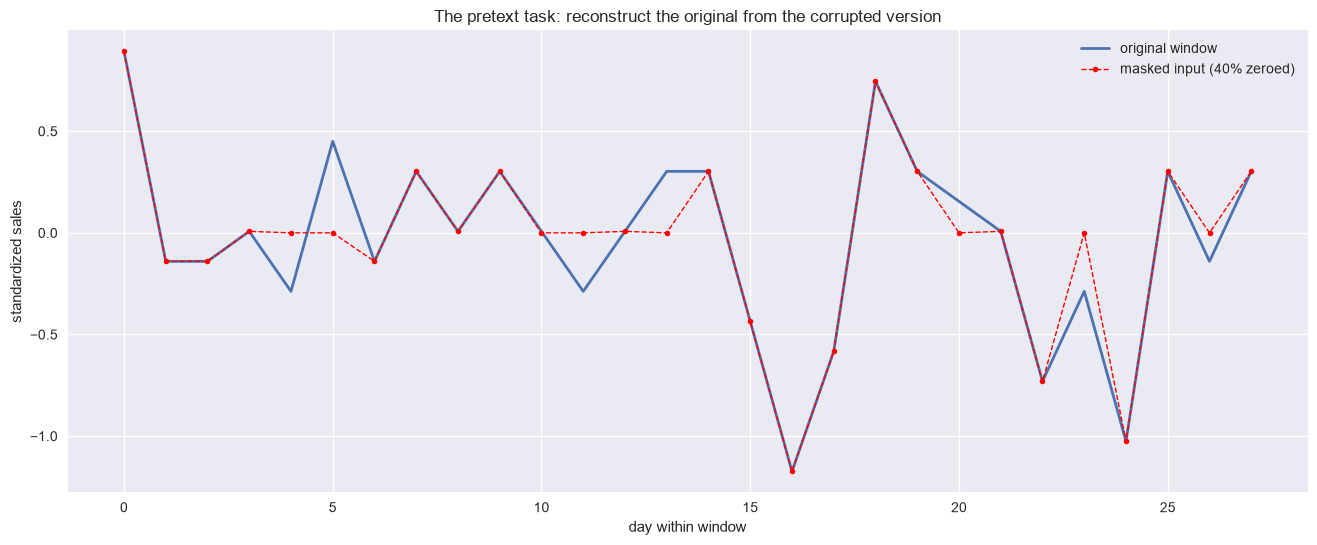

In [25]:
MASK_FRAC = 0.4   # fraction of timesteps zeroed out in each window
DEMO_IDX = 230    # a shoulder-season window, for plots

rng = np.random.default_rng(CFG.SEED)
mask = rng.random(X_src_tr.shape) < MASK_FRAC
X_src_masked = X_src_tr.copy()
X_src_masked[mask] = 0.0

# what the pretext task looks like: one window, intact vs. corrupted
plt.figure()
plt.plot(X_src_tr[DEMO_IDX].ravel(), linewidth=2, label='original window')
plt.plot(X_src_masked[DEMO_IDX].ravel(), 'ro--', linewidth=1, markersize=4, label='masked input (40% zeroed)')
plt.title('The pretext task: reconstruct the original from the corrupted version')
plt.xlabel('day within window')
plt.ylabel('standardized sales')
plt.legend()
plt.show()

Masking is three lines of NumPy: draw a uniform random number per tensor position, zero out positions where it falls below `MASK_FRAC`. Zeroing is a meaningful corruption *because* the data is standardized — zero is each series' own mean, so a masked day reads as "nothing to see here" rather than as an outlier. The plot shows a single training pair: the model will receive the red line and be scored on how well it reproduces the blue one. Note what this forces: filling a hole mid-week requires knowing where in the weekly cycle it sits, and filling several consecutive holes requires a sense of the local trend. The 40% rate follows the masked-autoencoding literature: mask too little and the task is trivial interpolation, too much and it becomes guesswork.

In [26]:
keras.utils.set_random_seed(CFG.SEED)

with keras.device(DEVICE):
    autoencoder = Sequential([
        Input(shape=(CFG.LOOK_BACK, 1)),
        GRU(CFG.UNITS, name='encoder'),          # same encoder shape as the forecaster
        RepeatVector(CFG.LOOK_BACK),             # broadcast the code across 28 steps
        GRU(CFG.UNITS, return_sequences=True),   # decoder
        TimeDistributed(Dense(1)),               # per-step reconstruction
    ])
autoencoder.compile(loss='mse', optimizer='adam')

start = time.time()
autoencoder.fit(X_src_masked, X_src_tr, epochs=CFG.PRETRAIN_EPOCHS,
                batch_size=CFG.PRETRAIN_BATCH, verbose=2)
print(f'masked-autoencoder pretraining took {time.time() - start:.0f} s')

Epoch 1/8


156/156 - 3s - 17ms/step - loss: 0.5258


Epoch 2/8


156/156 - 3s - 17ms/step - loss: 0.4911


Epoch 3/8


...

Epoch 7/8


156/156 - 3s - 17ms/step - loss: 0.4745


Epoch 8/8


156/156 - 3s - 17ms/step - loss: 0.4730


masked-autoencoder pretraining took 22 s


The architecture is the seq2seq skeleton from the previous episode, repurposed: the encoder GRU — *identical in shape and name to the forecaster's encoder*, which is what makes the coming weight transplant a one-liner — compresses the corrupted window into a 64-dimensional code; `RepeatVector` hands that code to every timestep of the decoder; the decoder GRU unrolls it back into a sequence; `TimeDistributed(Dense(1))` reads out one reconstructed value per day. The fit call is where self-supervision becomes visible: **the input is `X_src_masked` and the target is `X_src_tr`** — corrupted in, original out, `y` nowhere in sight. The 64-dim bottleneck is the pressure that makes this educational: 28 values cannot be memorized into 64 numbers without exploiting regularities, so regularities are what the encoder learns. (TimeNet pushed the same idea further by training one such autoencoder across many unrelated datasets at once.)

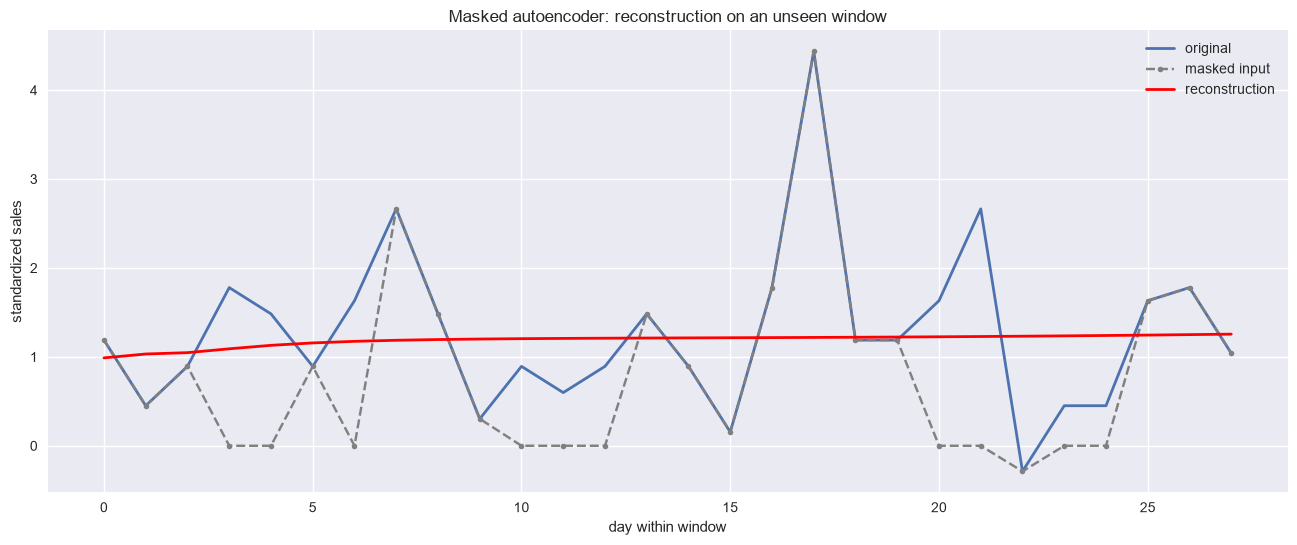

In [27]:
# how well does it infill? one source validation window
demo_masked = X_src_va[:1].copy()
demo_rng = np.random.default_rng(7)
demo_masked[demo_rng.random(demo_masked.shape) < MASK_FRAC] = 0.0
recon = autoencoder.predict(demo_masked, verbose=0)

plt.figure()
plt.plot(X_src_va[0].ravel(), linewidth=2, label='original')
plt.plot(demo_masked[0].ravel(), 'o--', color='gray', markersize=4, label='masked input')
plt.plot(recon[0].ravel(), 'r', linewidth=2, label='reconstruction')
plt.title('Masked autoencoder: reconstruction on an unseen window')
plt.xlabel('day within window')
plt.ylabel('standardized sales')
plt.legend()
plt.show()

A qualitative check on a window the autoencoder never trained on — and an honest look at it is worth more than a flattering one. The reconstruction (red) nails the window's **level** and slow drift, and essentially nothing else: the day-to-day structure is smoothed away into a near-flat line. That is not a bug in the training; it is what minimizing MSE through a 64-number bottleneck rationally does when the fine structure of noisy demand windows is hard to pin down — predicting each window's own average is a safe, low-loss strategy. But it is a warning sign for our purposes: an encoder whose code mostly says "this window sits 1.2 standard deviations above its mean" has learned something *true* and possibly something *insufficient* for forecasting, where next week's shape is the whole game. The transplant will tell.

In [28]:
# transplant the SSL encoder, then fine-tune in two stages
keras.utils.set_random_seed(CFG.SEED)

ssl_model = build_forecaster()
ssl_model.get_layer('encoder').set_weights(autoencoder.get_layer('encoder').get_weights())

# stage 1: warm up the (random) head with the encoder frozen
ssl_model.get_layer('encoder').trainable = False
ssl_model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=1e-3))
fit_on(ssl_model, X_tr, y_tr, X_va, y_va)

# stage 2: unfreeze everything at the gentle rate
ssl_model.get_layer('encoder').trainable = True
ssl_model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=CFG.FT_LR))
fit_on(ssl_model, X_tr, y_tr, X_va, y_va)

results['masked AE + fine-tune'] = evaluate_forecaster(ssl_model, X_test,
                                                       y_test_units, t_mean, t_std)
print('masked AE + fine-tune:', results['masked AE + fine-tune'])

stopped after 141 epochs, best val loss: 0.6119


stopped after 11 epochs, best val loss: 0.6125
masked AE + fine-tune: {'MAE': 15.85, 'RMSE': 20.15}


Two differences from rung 4's fine-tuning, both consequences of *what* was pretrained. First, only the **encoder** weights transfer — layer-targeted this time, `get_layer('encoder').set_weights(...)` — because the autoencoder's decoder reconstructs the past and is useless for predicting the future; the forecasting head starts random. Second, and because the head starts random, fine-tuning proceeds in **two stages**: first the frozen-encoder head warm-up (rung 3's recipe), then the full unfreeze at the gentle rate (rung 4's). Skipping the warm-up is a classic mistake worth naming: at `lr=1e-4` a random head barely trains, while at `lr=1e-3` its large early gradients shred the pretrained encoder before the head is even calibrated — we measured the one-stage variant at close to 3 RMSE points worse.

And the honest result: around **RMSE 20** — miles behind supervised pretraining (14.9), roughly level with training from scratch, still shy of seasonal naive. The reconstruction plot already told us why: the pretext was solved by encoding *levels*, and levels are nearly worthless here, because standardization already removed the level and forecasting demands committing to next week's *shape*. Reconstruction rewards summarizing what happened; with a modest, homogeneous source corpus, that objective shares less with forecasting than one might hope. The general lesson — echoed in the literature, where reconstruction-pretrained representations often need auxiliary help on downstream forecasting — is that **self-supervision is not free lunch; the pretext task must be aligned with the downstream task, and its benefits must be measured, not assumed**. When source labels for your actual task are free (as they are in forecasting), supervised pretraining is very hard to beat.

## Rung 6 — contrastive pretraining

**New ingredient: instance discrimination.** The second great self-supervised family abandons reconstruction entirely. **Contrastive learning** creates two randomly *augmented* views of each window and trains the encoder to make embeddings of the same window's views similar while pushing apart the views of different windows — teaching it what makes each window *itself*, invariant to nuisance perturbations. Frameworks like TS-TCC and TS2Vec elaborate this idea with temporal and hierarchical structure; we implement its clean core, then bolt the report-approved lightweight head — a **ridge regression** — onto the frozen encoder.

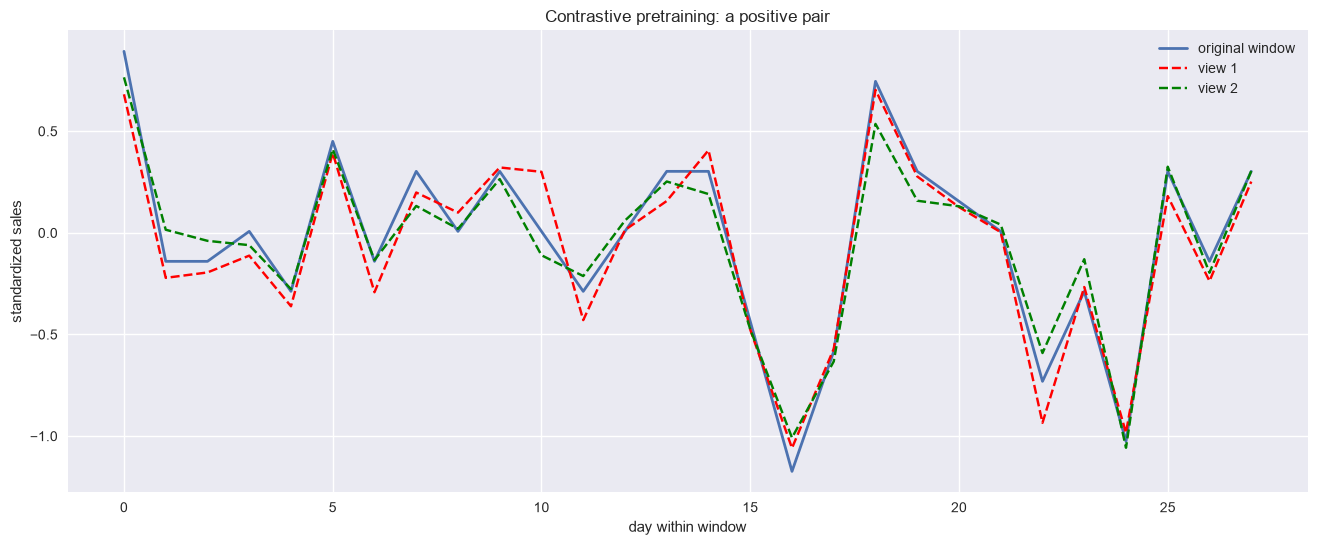

In [29]:
def augment(X, rng):
    """A random view of each window: amplitude scaling + additive jitter."""
    scale = rng.uniform(0.8, 1.2, (X.shape[0], 1, 1)).astype(np.float32)
    jitter = rng.normal(0.0, 0.1, X.shape).astype(np.float32)
    return X * scale + jitter

view_1 = augment(X_src_tr, np.random.default_rng(1))
view_2 = augment(X_src_tr, np.random.default_rng(2))

# two views of the same source window
plt.figure()
plt.plot(X_src_tr[DEMO_IDX].ravel(), linewidth=2, label='original window')
plt.plot(view_1[DEMO_IDX].ravel(), '--', color='red', label='view 1')
plt.plot(view_2[DEMO_IDX].ravel(), '--', color='green', label='view 2')
plt.title('Contrastive pretraining: a positive pair')
plt.xlabel('day within window')
plt.ylabel('standardized sales')
plt.legend()
plt.show()

The augmentations define what the encoder is told to ignore. **Amplitude scaling** (each window multiplied by a random factor in 0.8–1.2) declares overall size a nuisance; **jitter** (small Gaussian noise on every value) declares day-level noise a nuisance. What survives both is the window's *shape* — its weekly profile, trend direction, peak placement — so shape is what the embedding will encode. The plot shows one **positive pair**: two distortions of the same window that the encoder must map close together, while treating every other window in the batch as a **negative** to push away. One caveat from the literature to note in passing: an encoder trained to ignore amplitude can become *amplitude-agnostic*, a liability for downstream tasks where size matters — one reason production frameworks add mechanisms to reintroduce it. Choosing augmentations *is* choosing your invariances; it is the contrastive analogue of choosing the mask rate.

One simplification to be aware of: we draw the two views once, up front, and reuse them for all eight epochs. Full SimCLR-style training re-samples fresh augmentations for every batch, which strengthens the invariance signal at the cost of a custom data pipeline — worth the trouble at production scale, not for a pedagogical pretrain that lasts twenty seconds.

In [30]:
EMB_DIM = 64        # dimension of the projection the loss operates on
TEMPERATURE = 0.2   # sharpness of the softmax over similarities

keras.utils.set_random_seed(CFG.SEED)   # re-seed BEFORE building: reproducible init

with keras.device(DEVICE):
    # the encoder we intend to keep, plus a projection layer used only during pretraining
    enc_input = Input(shape=(CFG.LOOK_BACK, 1))
    embedding = GRU(CFG.UNITS, name='encoder')(enc_input)
    projection = Dense(EMB_DIM)(embedding)
    contrastive_encoder = Model(enc_input, projection)

    # siamese wrapper: one encoder applied to both views
    input_a = Input(shape=(CFG.LOOK_BACK, 1))
    input_b = Input(shape=(CFG.LOOK_BACK, 1))
    paired = keras.ops.stack([contrastive_encoder(input_a),
                              contrastive_encoder(input_b)], axis=1)
    contrastive_model = Model([input_a, input_b], paired)


def nt_xent(y_true, y_pred):
    """Normalized temperature-scaled cross-entropy (the SimCLR loss)."""
    z1 = keras.ops.normalize(y_pred[:, 0, :], axis=1)
    z2 = keras.ops.normalize(y_pred[:, 1, :], axis=1)
    z = keras.ops.concatenate([z1, z2], axis=0)                    # (2N, d)
    sim = keras.ops.matmul(z, keras.ops.transpose(z)) / TEMPERATURE
    n = keras.ops.shape(z1)[0]
    sim = sim - keras.ops.eye(2 * n) * 1e9                         # exclude self-matches
    targets = keras.ops.concatenate(
        [keras.ops.arange(n, 2 * n), keras.ops.arange(0, n)], axis=0)
    return keras.ops.mean(
        keras.losses.sparse_categorical_crossentropy(targets, sim, from_logits=True))

The most intricate cell of the notebook — the functional API earning its import. The **siamese wrapper** applies *one* shared encoder to two inputs (both views pass through the same weights — that is what makes them comparable) and stacks the two projections into a `(batch, 2, EMB_DIM)` tensor for the loss to unpack. A small `Dense` **projection layer** sits between encoder and loss, per standard practice: the loss shapes the projection space aggressively, and keeping it as a detachable adapter leaves the encoder's own features more broadly useful.

The **NT-Xent loss** reads as a classification problem in disguise. Normalize all `2N` projections to unit length (so dot products become cosine similarities), compute the full `2N × 2N` similarity matrix, and treat each row as the logits of a softmax question: *"which of the other 2N−1 embeddings is your partner view?"* The `targets` vector encodes the answer key — row `i`'s partner sits at `i+N` and vice versa — the diagonal is pushed to `−∞` so "myself" is never a legal answer, and `TEMPERATURE` divides the logits: lower values sharpen the softmax, making the loss concentrate on the hardest, most confusable negatives. Everything is written with **`keras.ops`**, the backend-agnostic tensor namespace — this exact code runs unchanged on torch, TensorFlow, or JAX.

In [31]:
contrastive_model.compile(loss=nt_xent, optimizer='adam')

# labels are irrelevant — the loss uses only y_pred — but fit() requires something
dummy_y = np.zeros((len(X_src_tr), 1), dtype=np.float32)

start = time.time()
contrastive_model.fit([view_1, view_2], dummy_y,
                      epochs=CFG.PRETRAIN_EPOCHS, batch_size=CFG.PRETRAIN_BATCH,
                      verbose=2)
print(f'contrastive pretraining took {time.time() - start:.0f} s')

Epoch 1/8


156/156 - 3s - 17ms/step - loss: 3.6493


Epoch 2/8


156/156 - 3s - 17ms/step - loss: 2.7851


Epoch 3/8


...

Epoch 7/8


156/156 - 3s - 16ms/step - loss: 2.1227


Epoch 8/8


156/156 - 2s - 16ms/step - loss: 2.0838


contrastive pretraining took 21 s


One idiom to flag: `fit` demands labels, but NT-Xent looks only at `y_pred` — the supervision signal is *baked into the batch structure* (row `i` of view 1 pairs with row `i` of view 2), so we pass a dummy zero array to satisfy the API. Reading the loss: with batch 256, the softmax has 511 candidate answers, so random guessing scores `ln(511) ≈ 6.2`; the printed loss dropping from ~3.6 toward ~2.1 means the encoder quickly becomes much better than chance at re-identifying windows through their distortions. Not perfect, either — nor should it be, since retail demand windows genuinely resemble one another; the hard negatives are hard because the domain repeats itself.

In [32]:
# frozen contrastive encoder -> ridge regression head on the target
feature_extractor = Model(enc_input, embedding)   # up to the GRU, skipping the projection

F_train = feature_extractor.predict(X_target, verbose=0)   # all 86 target windows
F_test = feature_extractor.predict(X_test, verbose=0)

ridge_head = Ridge(alpha=1.0).fit(F_train, y_target)
ridge_pred_units = ridge_head.predict(F_test) * t_std + t_mean

results['contrastive + ridge head'] = forecast_metrics(y_test_units.ravel(),
                                                       ridge_pred_units.ravel())
print('contrastive + ridge head:', results['contrastive + ridge head'])

contrastive + ridge head: {'MAE': 15.06, 'RMSE': 18.97}


Adaptation at its most frugal. `Model(enc_input, embedding)` carves out a **feature extractor** ending at the GRU — the projection layer, having served the loss, is discarded. The extractor turns each target window into a 64-number summary, and a **`Ridge`** regression maps summaries to seven-day forecasts: partial-parameter fine-tuning taken to its logical extreme, where the "head" is not even a neural layer. Two practical notes: with a frozen encoder there is no gradient-based overfitting to guard against, so all 86 windows go into the ridge fit (no validation split needed — `alpha` provides the regularization); and scikit-learn's `Ridge` handles the 7-output regression natively, fitting in milliseconds.

The score: around **RMSE 19** — a full point better than scratch and the masked autoencoder, clearly behind supervised transfer, and still a point shy of the seasonal-naive bar. A fair reading: instance discrimination *did* produce transferable features (shape-awareness demonstrably helps), but on a source corpus this small and homogeneous, and for a downstream task whose labels were free anyway, the discriminative pretext cannot match pretraining on the task itself. Where contrastive encoders earn their reputation is a different setting: one encoder pretrained once, then serving *many* downstream tasks — classification, anomaly detection, forecasting — each with its own cheap head; TS2Vec's near-supervised results across hundreds of such benchmarks are the flagship demonstration.

# When does transfer help?

Two experiments to map the boundaries of what we just saw. The first varies the thing our scenario held fixed — *how much* target history exists — to measure how transfer's advantage scales. The second varies the thing we quietly got right — *which* source domain to pretrain on — to show what happens when it is chosen badly.

## The sample-efficiency curve

The claim behind transfer learning is not "pretrained models are better", it is "pretrained models need **less target data** to get good". That is a claim about a curve, so we trace it: for target histories of 60, 120, 240 and 480 days, train a from-scratch model and a fully fine-tuned model under identical protocols, and compare test RMSE. Each history length gets its own scaling statistics — a subtle but necessary detail, since a 480-day window straddles different seasons than a 60-day one and its mean and standard deviation differ accordingly.

In [33]:
HISTORIES = [60, 120, 240, 480]   # days of target history made available

sample_eff = {}
for n_days in HISTORIES:
    chunk = history.iloc[-n_days:]
    m, s = chunk.mean(), chunk.std()
    X_h, y_h = make_windows(((chunk - m) / s).to_numpy(), CFG.LOOK_BACK, CFG.HORIZON)
    n_va = max(6, int(0.2 * len(X_h)))

    # test inputs re-scaled with THIS history's statistics; labels are unchanged
    X_te_h, _ = make_test_windows(target, m, s)

    row = {}
    for method in ['from scratch', 'full fine-tune']:
        keras.utils.set_random_seed(CFG.SEED)
        model = build_forecaster(lr=1e-3 if method == 'from scratch' else CFG.FT_LR)
        if method == 'full fine-tune':
            model.set_weights(pretrained_weights)
        fit_on(model, X_h[:-n_va], y_h[:-n_va], X_h[-n_va:], y_h[-n_va:], verbose=0)
        row[method] = evaluate_forecaster(model, X_te_h, y_test_units, m, s)['RMSE']
    sample_eff[n_days] = row
    print(f'{n_days:4d} days of target history -> {row}')

sample_eff_df = pd.DataFrame(sample_eff).T.rename_axis('target history (days)')
sample_eff_df

stopped after 56 epochs, best val loss: 0.9134
stopped after 11 epochs, best val loss: 0.5688
  60 days of target history -> {'from scratch': 27.23, 'full fine-tune': 15.22}


stopped after 59 epochs, best val loss: 0.5089


stopped after 84 epochs, best val loss: 0.2882
 120 days of target history -> {'from scratch': 20.05, 'full fine-tune': 14.85}


stopped after 11 epochs, best val loss: 0.5561


stopped after 11 epochs, best val loss: 0.2457
 240 days of target history -> {'from scratch': 26.2, 'full fine-tune': 14.65}


stopped after 83 epochs, best val loss: 0.2191


stopped after 35 epochs, best val loss: 0.2056
 480 days of target history -> {'from scratch': 14.22, 'full fine-tune': 13.82}


,from scratch,full fine-tune
target history (days),,
60,27.23,15.22
120,20.05,14.85
240,26.20,14.65
480,14.22,13.82


The loop re-runs the rung-1 and rung-4 recipes verbatim at each history length — same factory, same early stopping, same seed before every build so that differences come from the data, not the dice. Note that the fine-tuned model starts from the **same** `pretrained_weights` every time; pretraining happens once, adaptation is what varies. The re-derived test inputs (`X_te_h`) are the consequence of per-history scaling: each model must read the test period through the same statistics it trained under.

Two patterns in the table. The fine-tuned column is **low and steady** — roughly 15.2 down to 13.8 RMSE across an eightfold change in target data; even 60 days (a mere 26 windows!) lands within a point and a half of the best result. The scratch column is **high and erratic** — improving in fits and starts and *not even monotonically*: with data this scarce, training is so seed- and split-sensitive that 240 days can score worse than 120. That instability is itself a finding: below a few hundred days, a from-scratch deep model is not merely worse on average, it is *unreliable*. Only at 480 days does scratch pull within striking distance.

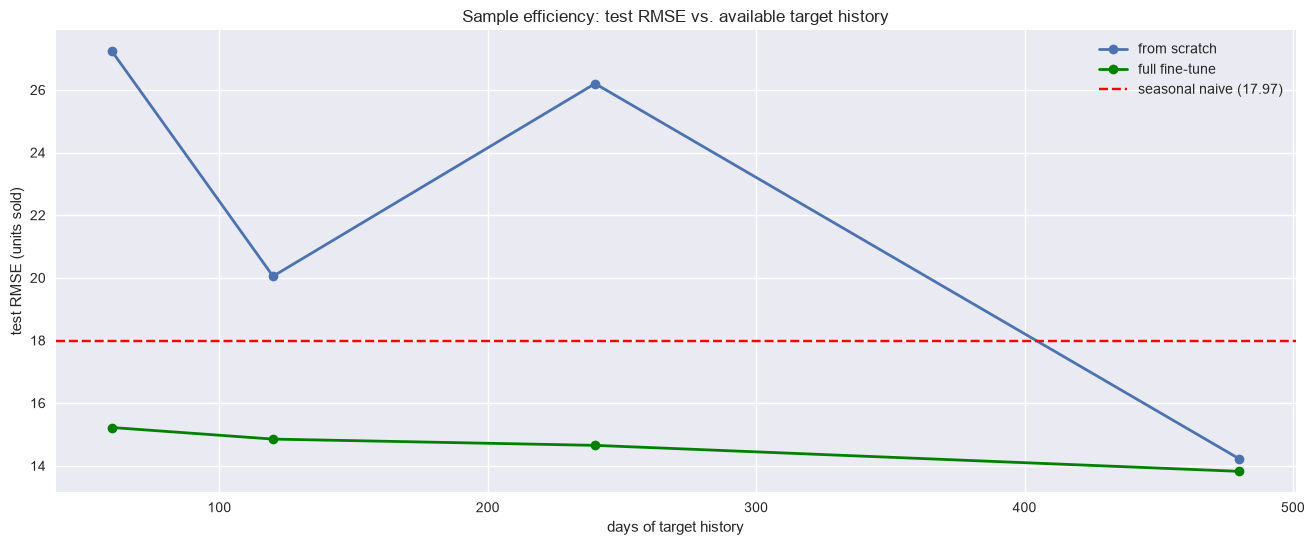

In [34]:
plt.figure()
sample_eff_df['from scratch'].plot(marker='o', linewidth=2, label='from scratch')
sample_eff_df['full fine-tune'].plot(marker='o', linewidth=2, color='green', label='full fine-tune')
plt.axhline(results['seasonal naive']['RMSE'], color='red', linestyle='--',
            label=f"seasonal naive ({results['seasonal naive']['RMSE']})")
plt.title('Sample efficiency: test RMSE vs. available target history')
plt.xlabel('days of target history')
plt.ylabel('test RMSE (units sold)')
plt.legend()
plt.show()

The sample-efficiency picture, with the seasonal-naive bar drawn in red for orientation. Read it as a practitioner's decision chart: the vertical gap between the curves is what pretraining is worth at each data size, and it is largest exactly where forecasting is hardest — the young-series regime on the left, where fine-tuning beats scratch by ten or more RMSE points and scratch cannot even hold the naive line. As target history grows the curves converge, and the chart hints at the eventual crossover regime: given a few years of history, the target can support its own model and transfer becomes a convenience rather than a necessity. The literature's summary — *transfer learning buys the most precisely when you have the least* — is not a slogan; on this dataset it is simply what the curve looks like.

## Negative transfer

**New ingredient: a mismatched source.** Everything so far pretrained on demand series to forecast a demand series. But the promise "pretrain on anything big, fine-tune on your problem" is tempting precisely when related data is scarce too — so what does an *unrelated* source buy? We pretrain the same architecture on ten years of daily Melbourne minimum temperatures (a familiar series from the previous episode): a fine dataset, honest daily dynamics, annual seasonality — and nothing whatsoever to do with retail.

In [35]:
# pretrain on weather, evaluate on store demand
temps = pd.read_csv(CFG.data_folder + 'daily-min-temperatures.csv', parse_dates=['Date'])
temps_z = ((temps.Temp - temps.Temp.mean()) / temps.Temp.std()).to_numpy()
X_weather, y_weather = make_windows(temps_z, CFG.LOOK_BACK, CFG.HORIZON)
print(f'weather windows: {len(X_weather):,}')

keras.utils.set_random_seed(CFG.SEED)
weather_model = build_forecaster()
weather_model.fit(X_weather, y_weather, epochs=CFG.PRETRAIN_EPOCHS,
                  batch_size=CFG.PRETRAIN_BATCH, verbose=0)

results['weather zero-shot'] = evaluate_forecaster(weather_model, X_test,
                                                   y_test_units, t_mean, t_std)
print('weather zero-shot:  ', results['weather zero-shot'])

# ... and the full fine-tuning recipe on top of the weather weights
keras.utils.set_random_seed(CFG.SEED)
weather_ft_model = build_forecaster(lr=CFG.FT_LR)
weather_ft_model.set_weights(weather_model.get_weights())
fit_on(weather_ft_model, X_tr, y_tr, X_va, y_va)
results['weather fine-tune'] = evaluate_forecaster(weather_ft_model, X_test,
                                                   y_test_units, t_mean, t_std)
print('weather fine-tune:  ', results['weather fine-tune'])

weather windows: 3,616


weather zero-shot:   {'MAE': 16.78, 'RMSE': 20.78}


stopped after 47 epochs, best val loss: 0.6542
weather fine-tune:   {'MAE': 16.84, 'RMSE': 20.66}


The cell replays rungs 2 and 4 with only the source swapped — same standardization, same architecture, same fine-tuning recipe — so the comparison isolates a single variable: **source relevance**. The verdict is unambiguous. Weather zero-shot scores around RMSE 21 (worse than scratch — the encoder confidently applies temperature physics to shop demand: smooth mean-reverting drifts, no weekly rhythm, since weather does not know about weekends). Fine-tuning claws back only to roughly scratch level: 69 windows are enough to calibrate a *right* representation, not to rebuild a *wrong* one. Compare the same recipe on the demand source: 14.9.

This is **negative transfer**, and its practical sting is that it is invisible without a scratch baseline to compare against — the pipeline runs, the losses decrease, the forecasts look plausible. Two defenses are standard. First, *always* train the scratch baseline; it is cheap insurance. Second, choose sources by measured similarity rather than availability — the classification-transfer literature does this by ranking candidate source datasets with Dynamic Time Warping distance to the target and pretraining on the nearest, which reliably predicts which transfers will help. "Pretrain on something big" is half the recipe; the other half is "…that resembles your target".

# Head-to-head comparison

Every method in this notebook, one table, one chart — all scored by the identical walk-forward protocol on the same twelve test weeks.

In [36]:
comparison = pd.DataFrame(results).T

# bookkeeping, keyed by method name so no row can be silently mislabeled
source_used = {
    'persistence': 'none', 'seasonal naive': 'none', 'from scratch': 'none',
    'zero-shot transfer': 'supervised', 'head-only fine-tune': 'supervised',
    'full fine-tune': 'supervised',
    'masked AE + fine-tune': 'self-supervised',
    'contrastive + ridge head': 'self-supervised',
    'weather zero-shot': 'mismatched', 'weather fine-tune': 'mismatched',
}
target_labels_used = {
    'persistence': 'no', 'seasonal naive': 'no', 'from scratch': 'yes',
    'zero-shot transfer': 'no', 'head-only fine-tune': 'yes',
    'full fine-tune': 'yes', 'masked AE + fine-tune': 'yes',
    'contrastive + ridge head': 'yes',
    'weather zero-shot': 'no', 'weather fine-tune': 'yes',
}
comparison['source pretraining'] = comparison.index.map(source_used)
comparison['uses target labels'] = comparison.index.map(target_labels_used)
comparison = comparison.sort_values('RMSE')
comparison

,MAE,RMSE,source pretraining,uses target labels
full fine-tune,11.58,14.85,supervised,yes
head-only fine-tune,12.30,15.36,supervised,yes
zero-shot transfer,12.65,15.63,supervised,no
seasonal naive,13.61,17.97,none,no
contrastive + ridge head,15.06,18.97,self-supervised,yes
from scratch,15.82,20.05,none,yes
masked AE + fine-tune,15.85,20.15,self-supervised,yes
weather fine-tune,16.84,20.66,mismatched,yes
weather zero-shot,16.78,20.78,mismatched,no
persistence,24.14,29.04,none,no


The scoreboard, sorted by RMSE, with two bookkeeping columns that make the pattern legible: what kind of *source pretraining* each method used, and whether it consumed *target labels*. (The columns are keyed by method name, not by position — a small robustness habit for tables assembled by hand.) Reading from the top: the three supervised-transfer variants occupy the podium, and even zero-shot — which used **no target labels at all** — beats everything trained on the target alone. Seasonal naive sits above the entire self-supervised contingent and both weather transfers: a sobering mid-table line worth respecting. The bottom half collects the two ways to waste a deep network: train it on too little data (scratch, and the weather transfers that amount to the same thing), or pretrain it on a task that does not carry (masked reconstruction, here).

The compact summary this table supports: **matched-source supervised pretraining + gentle full fine-tuning** cut the error of the from-scratch approach by roughly a quarter, and cleared the strong naive baseline by three RMSE points, on a target with four months of history.

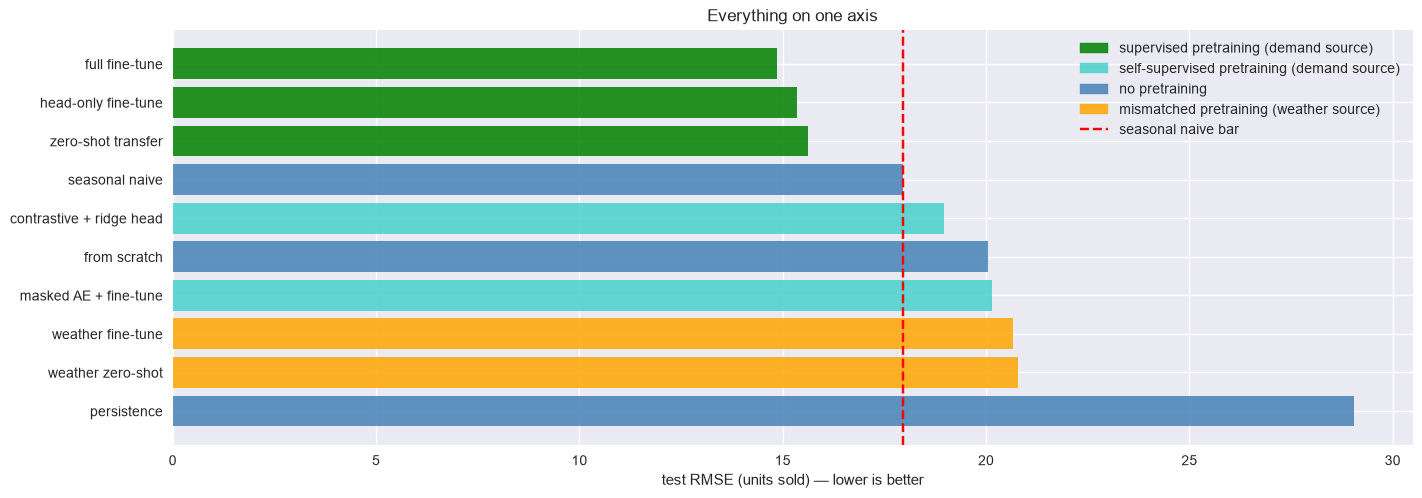

In [37]:
plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2 * 0.9))
palette = {'supervised': 'green', 'self-supervised': 'mediumturquoise',
           'none': 'steelblue', 'mismatched': 'orange'}
colors = comparison['source pretraining'].map(palette)
plt.barh(comparison.index[::-1], comparison['RMSE'][::-1],
         color=colors[::-1], alpha=0.85)
plt.axvline(results['seasonal naive']['RMSE'], color='red', linestyle='--',
            label='seasonal naive bar')
legend_labels = {'supervised': 'supervised pretraining (demand source)',
                 'self-supervised': 'self-supervised pretraining (demand source)',
                 'none': 'no pretraining',
                 'mismatched': 'mismatched pretraining (weather source)'}
handles = [Patch(color=palette[k], alpha=0.85, label=v)
           for k, v in legend_labels.items()]
plt.legend(handles=handles + plt.gca().get_legend_handles_labels()[0])
plt.xlabel('test RMSE (units sold) — lower is better')
plt.title('Everything on one axis')
plt.show()

The same information on one axis, color-coded by pretraining source: green for supervised pretraining on the matched demand source, turquoise for self-supervised pretraining on that same source, blue for no pretraining at all, orange for the mismatched weather source — with the seasonal-naive bar as the red line every method must clear to justify its complexity. The visual summary of the episode fits in one sentence: on this target, **the only bars left of the red line are the green ones** — deep learning earned its keep exactly and only when it arrived pretrained on relevant data, *on the task itself*. The turquoise bars used the very same source and still fell short: relevant data alone was not enough, the pretext had to match the downstream task too.

# Where to go next

This notebook walked the *custom* pretraining path: we owned the source data, the pretext tasks, and the fine-tuning schedules. Three directions extend it.

**Smarter fine-tuning.** Our two configurations — frozen encoder and full unfreeze — are the endpoints of a spectrum the literature has filled in. *Parameter-level collaboration* regularizes fine-tuned weights toward their pretrained values (an L2 tether instead of a hard freeze); *model-level* approaches split the network into components (trend vs. seasonal sub-networks) adapted at different rates; discriminative learning rates unfreeze layer by layer, top first. All are refinements of the same intuition we used: trust pretrained features in proportion to how little target data you hold.

**Domain adaptation.** We adapted with labeled target data. When the target has *no* labels at all, the problem becomes unsupervised domain adaptation — aligning source and target feature distributions so a source-trained predictor transfers anyway (adversarial feature alignment à la VRADA/CoDATS, frequency-domain alignment, and more). The field is organized along axes worth knowing even before you need them: what you may access during adaptation (both domains; only a pretrained model — *source-free*; only API predictions — *black-box*), and how the label spaces relate (identical, partial, open-set). Each relaxation trades data access for difficulty.

**Foundation models.** Everything we built by hand — pretrain on a corpus, transfer, adapt cheaply — is exactly what **time series foundation models** (Chronos, TimesFM, MOMENT, MOIRAI, Lag-Llama, TinyTimeMixer) productize at scale: transformer-family architectures pretrained on millions of heterogeneous series, applied zero-shot or lightly fine-tuned. Our zero-shot rung is the honest miniature of that paradigm, and our results explain both its appeal (zero-shot beat local training here, with a source of just fifty series) and its limits (a matched small source plus fine-tuning may still beat a generic giant — the negative-transfer lesson scales up too). When you next face a young series, the practical playbook is the ladder of this notebook: naive baselines first, a zero-shot foundation model or matched-source pretrain second, gentle fine-tuning third — and the scratch baseline always, as insurance against transfer that quietly hurts.

Two closing cautions, both restatements of things the numbers already said. Validation for anything transfer-related must remain chronological — walk-forward splits, purged folds for panels — because pretraining multiplies the ways future information can leak into the past. And every claim in this notebook came with a baseline attached; keep that habit. *Pretraining is powerful, but it is a hypothesis about your data, and hypotheses get tested.*